In [37]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

**Columns description**
- gender: Customer's gender (Male/Female)
- SeniorCitizen: The customer is a senior citizen (1 = Yes, 0 = No)
- Partner: Whether the customer has a partner (Yes/No)
- Dependents: Whether the customer has dependents (Yes/No)
- tenure: Number of months the customer has stayed with the company
- PhoneService: Whether the customer has a phone service (Yes/No)
- MultipleLines: Whether the customer has multiple phone lines (No, Yes, No phone service)
- InternetService: Type of internet service (DSL, Fiber optic, No)
- OnlineSecurity: Whether the customer has online security (Yes, No, No internet service)
- OnlineBackup: Whether the customer has online backup (Yes, No, No internet service)
- DeviceProtection: Whether the customer has device protection (Yes, No, No internet service)
- TechSupport: Whether the customer has tech support (Yes, No, No internet service)
- StreamingTV: Whether the customer has streaming TV (Yes, No, No internet service)
- StreamingMovies: Whether the customer has streaming movies (Yes, No, No internet service)
- Contract: Type of contract (Month-to-month, One year, Two year)
- PaperlessBilling: Whether the customer has paperless billing (Yes/No)
- PaymentMethod: Payment method used (Electronic check, Mailed check, Bank transfer, Credit card)
- MonthlyCharges: Monthly charges the customer pays
- TotalCharges: Total amount charged to the customer
- Churn: Whether the customer has churned (Yes/No)

# EDA

In [14]:
df_churn = pd.read_csv('data/customer_churn_telecom_services.csv')
df_churn.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_churn.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [4]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Churn Rate (Yes): 26.54%
Churn Rate (No): 73.46%


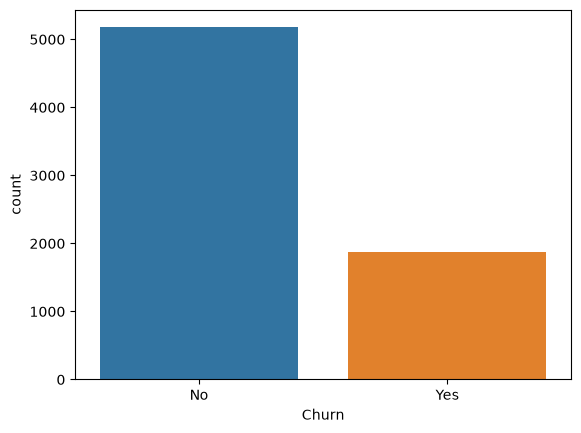

In [5]:
# Churn = Yes significa que o cliente cancelou o serviço e deixou de ser cliente da empresa.
sns.countplot(
    data=df_churn,
    x='Churn',
    hue='Churn',
)

print(f"Churn Rate (Yes): {(df_churn['Churn'] == 'Yes').sum() / len(df_churn) * 100:.2f}%")
print(f"Churn Rate (No): {(df_churn['Churn'] == 'No').sum() / len(df_churn) * 100:.2f}%")

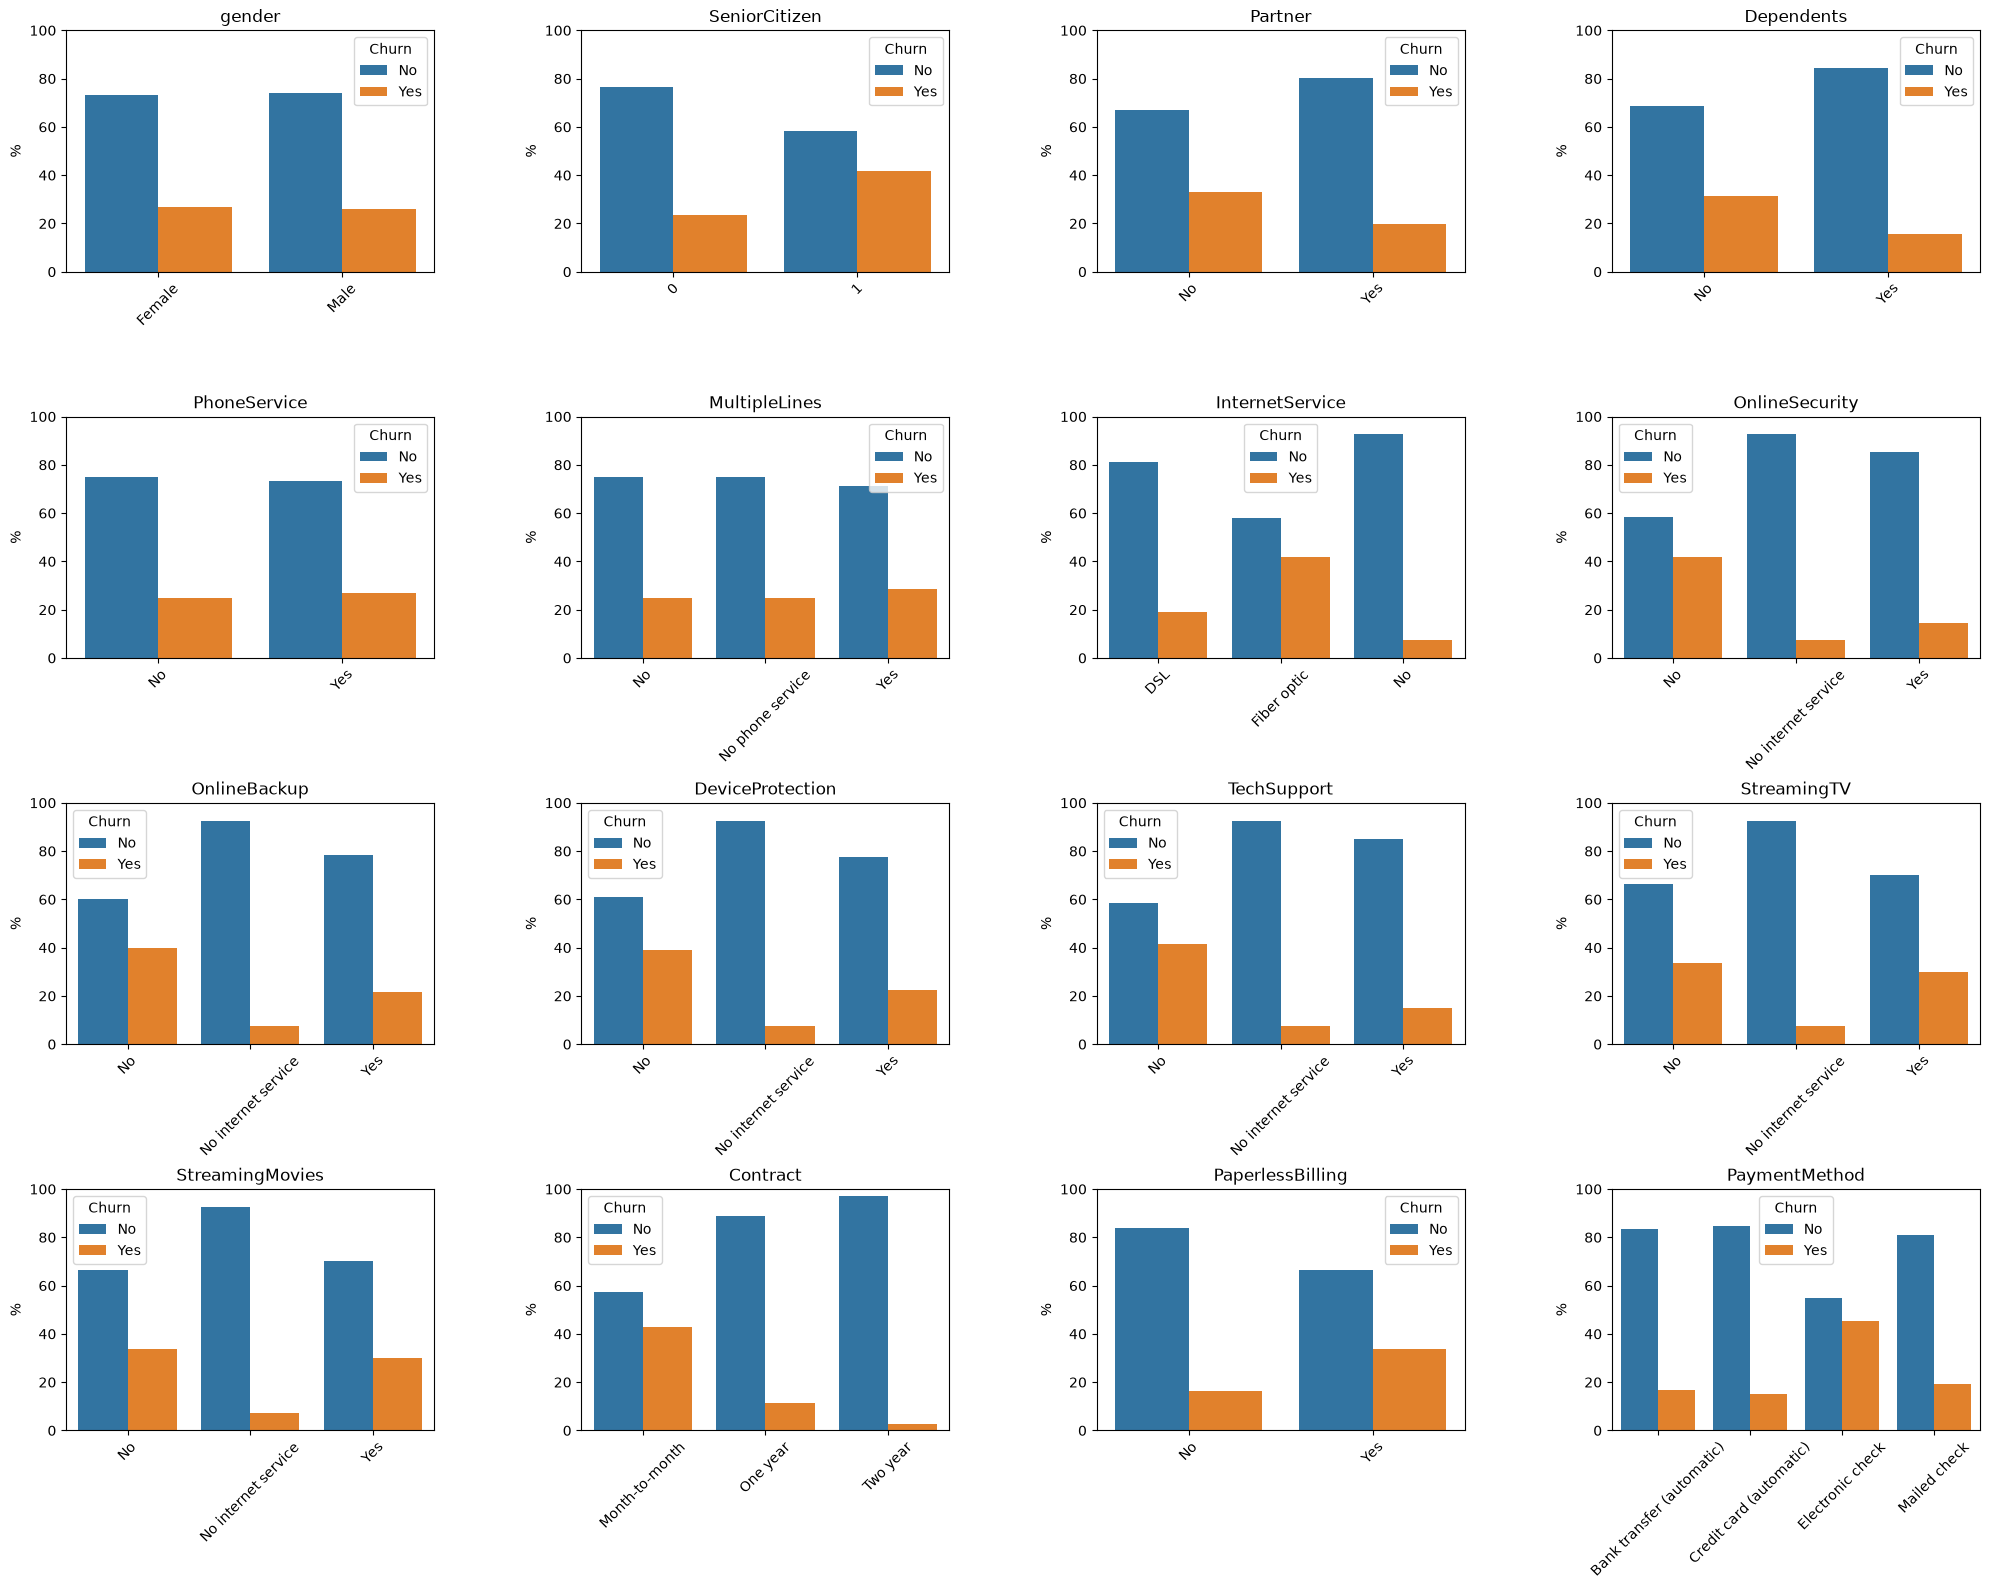

In [27]:
cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]


df_churn['Churn_num'] = (df_churn['Churn'] == 'Yes').astype(int)

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    percentual = (
        pd.crosstab(
            df_churn[col],
            df_churn['Churn'],
            normalize='index'
        )
        .mul(100)
        .reset_index()
    )

    percentual = percentual.melt(
        id_vars=col,
        value_vars=['No', 'Yes'],
        var_name='Churn',
        value_name='Percentual'
    )

    sns.barplot(
        data=percentual,
        x=col,
        y='Percentual',
        hue='Churn',
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_ylabel('%')
    axes[i].set_ylim(0, 100)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.show()

Na maioria das classes a proporção entre clientes que cancelaram ou não o serviço parece estar equilibrada, com o número de clientes que não cancelaram se mantendo significativamente maior em cada uma das categorias. Exceções notáveis:

- Forma de contrato
    - A forma de contrato tem uma relação notável no Churn rate, Isso sugere que vínculos contratuais mais longos estão associados a uma maior retenção de clientes, seja pela menor flexibilidade para cancelamento ou por um maior comprometimento com o serviço.

- Clientes sem serviço de internet
    - Clientes sem serviço de internet apresentam taxas de churn significativamente menores que os demais grupos. Uma possível explicação é que esses clientes possuem um relacionamento mais simples com a empresa, estando menos expostos a problemas de qualidade de conexão e a comparações frequentes com concorrentes. Além disso, é importante investigar possíveis efeitos de variáveis como o tipo de contrato, que podem estar contribuindo para essa diferença.

- Forma de pagamento
    - Por fim, entre os métodos de pagamento o cheque eletrônico apresenta um churn rate significativamente maior que os outros, o que pode se dar por conta de uma experiência de pagamento menos conveniente em comparação aos outros métodos.

In [7]:
from IPython.display import display

for col in ['InternetService', 'TechSupport', 'OnlineSecurity']:

    print(f'\n=== {col} x Contract ===')

    display(
        pd.crosstab(
            df_churn[col],
            df_churn['Contract'],
            normalize='index'
        )
    )


=== InternetService x Contract ===


Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,0.505163,0.235440,0.259397
Fiber optic,0.687339,0.174096,0.138566
No,0.343381,0.238532,0.418087



=== TechSupport x Contract ===


Contract,Month-to-month,One year,Two year
TechSupport,,,
No,0.771667,0.160380,0.067953
No internet service,0.343381,0.238532,0.418087
Yes,0.328278,0.270059,0.401663



=== OnlineSecurity x Contract ===


Contract,Month-to-month,One year,Two year
OnlineSecurity,,,
No,0.752144,0.159234,0.088622
No internet service,0.343381,0.238532,0.418087
Yes,0.356612,0.273403,0.369985


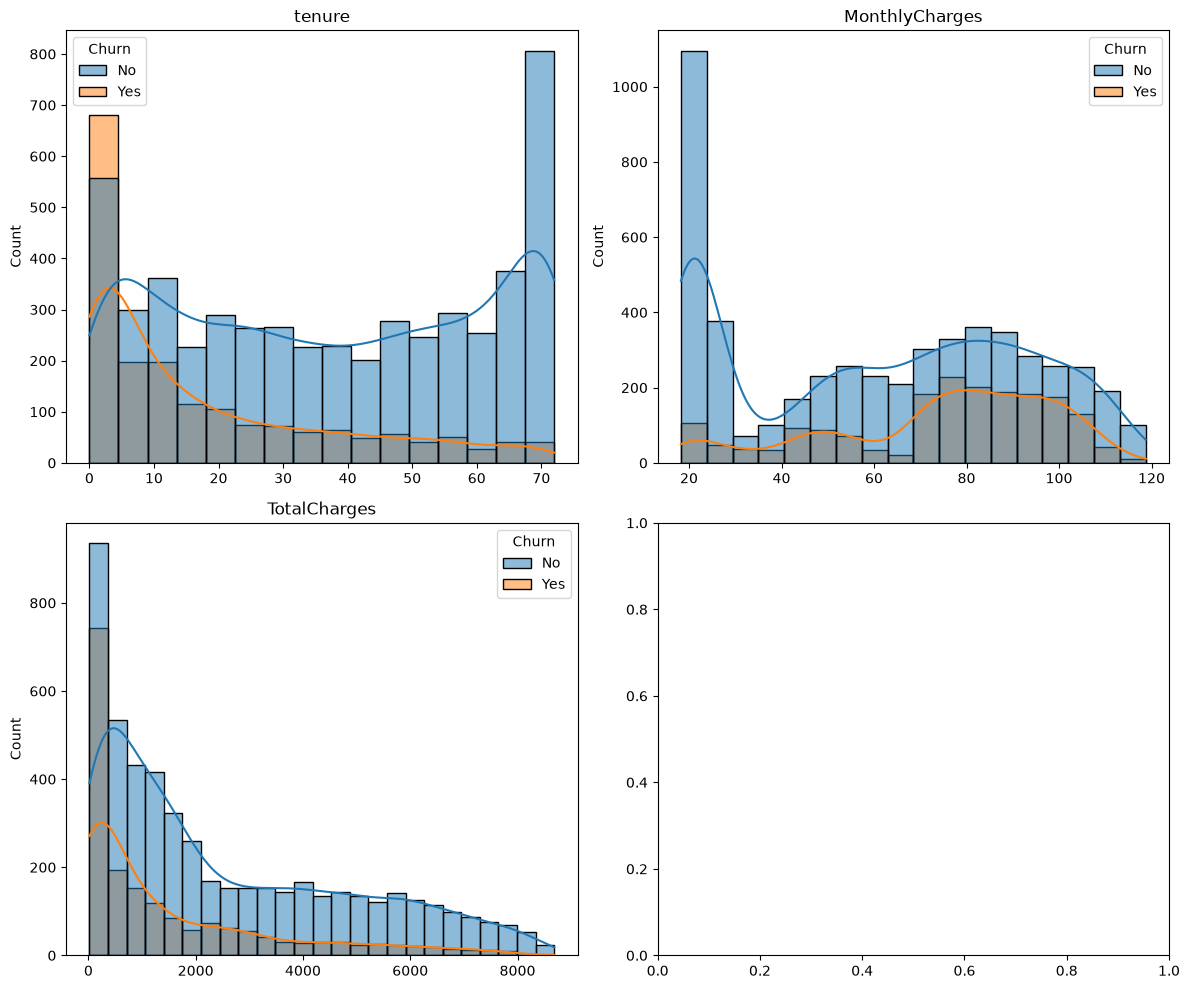

In [9]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 5*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        data=df_churn,
        x=col,
        hue='Churn',
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_xlabel('')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

A relação entre as variáveis númericas e o churn aparenta ser bastante intuitiva:

- Clientes com relacionamentos mais longos (ternure) tendem a cancelar menos
- Clientes com mensalidades menores tendem a cancelar menos
- A distribuição entre as duas classes é parecida quando observamos o total pago. Entretanto, clientes que permanecem na empresa tendem a acumular valores totais mais elevados. Esse resultado é esperado, uma vez que TotalCharges está fortemente associado ao tempo de permanência (tenure), e clientes de longo prazo naturalmente acumulam um volume maior de pagamentos ao longo do relacionamento.

In [28]:
services = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

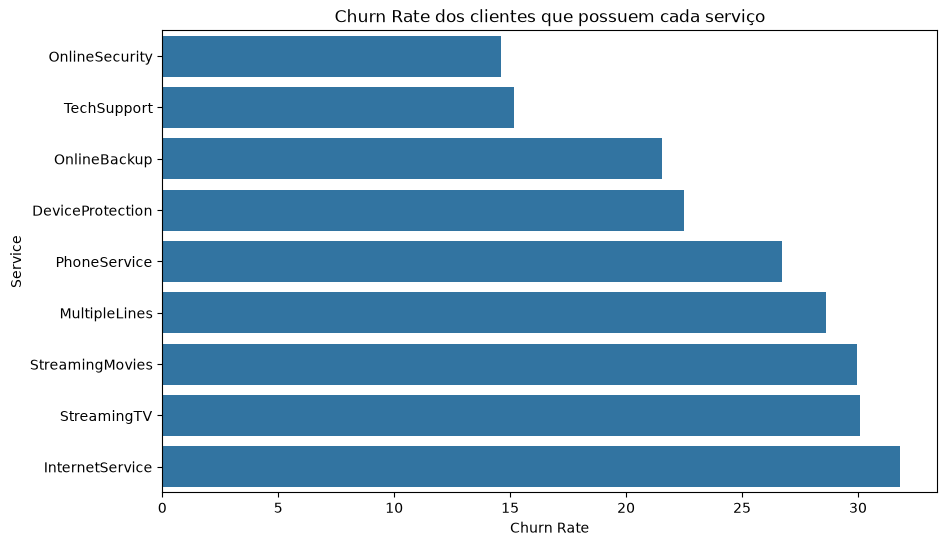

In [30]:
retencao = []

for service in services:

    if service == 'InternetService':
        mask = df_churn[service].isin(['DSL', 'Fiber optic'])
    else:
        mask = df_churn[service] == 'Yes'

    churn_rate = (
        df_churn.loc[mask, 'Churn_num']
        .mean()
        * 100
    )

    retencao.append({
        'Service': service,
        'Churn Rate': churn_rate
    })

retencao = (
    pd.DataFrame(retencao)
    .sort_values('Churn Rate')
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=retencao,
    x='Churn Rate',
    y='Service'
)

plt.title('Churn Rate dos clientes que possuem cada serviço')
plt.show()

# Pré-processamento

## Dados Ausentes

In [54]:
df_churn = pd.read_csv('data/customer_churn_telecom_services.csv')

In [55]:
df_churn.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [56]:
df_na = df_churn[df_churn.isna().any(axis=1)]
df_na.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Apenas a coluna **TotalCharges** apresenta valores ausentes e nesse grupo de clientes todos possuem ternure=0, ou seja, são clientes que iniciaram recentemente o relacionamento com a empresa e, portanto, ainda não acumularam cobranças. Por esse motivo, os valores ausentes serão substituidos por 0.

In [57]:
df_churn.fillna(0, inplace=True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## Outliers

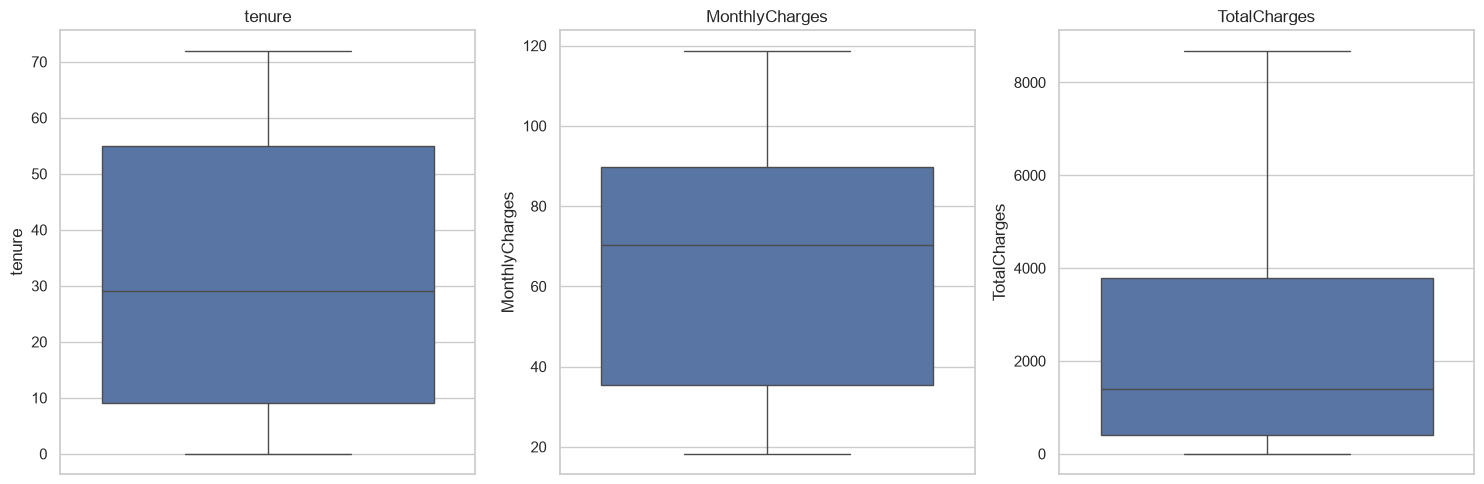

In [58]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):

    sns.boxplot(
        y=df_churn[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

O boxplot indica que não há presença de outliers entre os dados

## Encoding

In [59]:
for col in df_churn.select_dtypes(include='str').columns:
    print(f'\n=== {col} ===')
    display(df_churn[col].value_counts())


=== gender ===


gender
Male      3555
Female    3488
Name: count, dtype: int64


=== Partner ===


Partner
No     3641
Yes    3402
Name: count, dtype: int64


=== Dependents ===


...

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


=== PaymentMethod ===


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


=== Churn ===


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [60]:
# no internet service e no phone service são categorias que indicam a ausência de um serviço, então vamos substituir por 'No'
df_churn.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)

# contract é uma variável ordinal, então vamos mapear os valores para números inteiros
df_churn['Contract'] = df_churn['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# categorias binárias
df_churn['gender'] = df_churn['gender'].map({
    'Female': 0,
    'Male': 1
})

for col in df_churn.select_dtypes(include='str').columns:
    df_churn[col] = df_churn[col].map({
        'No': 0,
        'Yes': 1
    })


# para as variáveis nominais, vamos usar one-hot encoding
nominal_cols = [
    'InternetService',
    'PaymentMethod'
]

df_churn = pd.get_dummies(
    df_churn,
    columns=nominal_cols,
    drop_first=True
)

In [61]:
df_churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,29.85,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,1889.50,0
2,1,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,108.15,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,151.65,1


## Normalização

Inicialmente será feita a divisão estratificada dos conjuntos de treino, teste e validação. Essa abordagem garante que a proporção das classes da variável alvo (Churn) seja preservada em todos os conjuntos. 

Em seguida, será realizada a etapa de padronização das variáveis numéricas. Para evitar vazamento de dados, o ajuste do scaler será realizado exclusivamente sobre o conjunto de treino. O scaler será então utilizados para transformar os conjuntos de validação e teste.

In [62]:
X = df_churn.drop(columns=['Churn'])
y = df_churn['Churn']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

print(f'Train: {X_train.shape}, {y_train.shape}')
print(f'Validation: {X_val.shape}, {y_val.shape}')
print(f'Test: {X_test.shape}, {y_test.shape}')

Train: (4930, 17), (4930,)
Validation: (1056, 17), (1056,)
Test: (1057, 17), (1057,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

print(f'Train: {X_train.shape}, {y_train.shape}')
print(f'Validation: {X_val.shape}, {y_val.shape}')
print(f'Test: {X_test.shape}, {y_test.shape}')

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [65]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

train = X_train_scaled.copy()
train['Churn'] = y_train.values

val = X_val_scaled.copy()
val['Churn'] = y_val.values

test = X_test_scaled.copy()
test['Churn'] = y_test.values

train.to_csv('data/train.csv', index=False)
val.to_csv('data/validation.csv', index=False)
test.to_csv('data/test.csv', index=False)